# Workflows and Agents with LangGraph
## A Concept-by-Concept Walkthrough

**Module — Agentic AI · LangGraph · Workflow Patterns**  
**Nunnari Academy — Generative AI & Agentic AI Program**

---

This notebook is a single, self-contained tour of the six core building blocks every agentic AI engineer must know:

| # | Pattern | One-line Definition |
|---|---------|---------------------|
| 0 | **LLM Augmentations** | Give a base LLM superpowers — structured output, tools, memory |
| 1 | **Prompt Chaining** | Sequence LLM calls; each one builds on the last |
| 2 | **Parallelization** | Fan out independent LLM calls, then aggregate |
| 3 | **Routing** | Classify the input, then dispatch to a specialist |
| 4 | **Orchestrator–Worker** | A planner spawns dynamic workers and synthesizes their outputs |
| 5 | **Evaluator–Optimizer** | One LLM generates, another critiques, loop until quality is met |
| 6 | **Agent** | Let the LLM decide its own tool calls in a loop until done |

**The big mental model:**

> **Workflows** have predetermined code paths. The developer wires the graph; the LLM only fills in the blanks.  
> **Agents** have dynamic code paths. The LLM itself decides what to do next.

Workflows are predictable, debuggable, and fast. Agents are flexible but harder to reason about. Most production systems mix the two — a workflow shell with an agent tucked inside one of its nodes.

Reference: [LangGraph: Workflows & Agents](https://docs.langchain.com/oss/python/langgraph/workflows-agents)

## 1. Environment Setup

We use `langgraph` for the graph framework and `langchain-openai` for the model. The same patterns work with any chat model — Anthropic, Google, local Ollama — only the import line changes.

In [20]:
# !pip install -q langchain langchain-openai langgraph python-dotenv pydantic

In [3]:
import os
import operator
from typing import TypedDict, Annotated, Literal, List
from dotenv import load_dotenv

from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.types import Send
from langgraph.func import entrypoint, task
from langgraph.prebuilt import create_react_agent

from IPython.display import Image, display

load_dotenv()
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY not found in environment."

# One model used everywhere so cost and behaviour stay predictable
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

import warnings
warnings.filterwarnings("ignore")

print("Setup complete.")

Setup complete.


## 2. LLM Augmentations

Before any pattern, you need to know the three ways to extend a base LLM. Every pattern below is built on at least one of these.

| Augmentation | What it gives you | API |
|--------------|-------------------|-----|
| **Structured Output** | Guaranteed JSON shape | `llm.with_structured_output(Schema)` |
| **Tool Calling** | LLM can call Python functions | `llm.bind_tools([fn1, fn2])` |
| **Memory** | Conversation history persists | LangGraph `MessagesState` + checkpointer |

![Augmented LLM](https://www-cdn.anthropic.com/images/4zrzovbb/website/d3083d3f40bb2b6f477901cc9a240738d3dd1371-2401x1000.png)

*Diagram: the augmented LLM — a base model wrapped with retrieval, tools, and memory. Source: [Anthropic, *Building Effective Agents*](https://www.anthropic.com/engineering/building-effective-agents).*

### 2.1 Structured Output

Free-form LLM text is hard to consume in code. Structured output forces the model to return a Pydantic-shaped object, so downstream code never has to regex-parse a paragraph again.

In [4]:
class SearchQuery(BaseModel):
    """A web-search query crafted by the LLM."""
    search_query: str = Field(description="Web-search-optimized query.")
    justification: str = Field(description="Why this query is relevant.")

structured_llm = llm.with_structured_output(SearchQuery)
result = structured_llm.invoke("Find me research on Calcium CT scoring for heart disease.")

print("Type:         ", type(result).__name__)
print("search_query: ", result.search_query)
print("justification:", result.justification)

Type:          SearchQuery
search_query:  Calcium CT scoring heart disease research studies
justification: This query targets specific research studies and articles related to the use of Calcium CT scoring in assessing heart disease, which is essential for understanding its effectiveness and applications in clinical practice.


### 2.2 Tool Calling

Bind plain Python functions to the LLM. The model decides *when* to call them, *what* arguments to pass, and reads the return value back. The `@tool` decorator + the docstring are how the LLM learns each tool's contract.

In [5]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

@tool
def add(a: int, b: int) -> int:
    """Add a and b."""
    return a + b

llm_with_tools = llm.bind_tools([multiply, add])
msg = llm_with_tools.invoke("What is 7 times 8, then add 3 to the result?")

# The model returns *tool_calls* — not the final answer yet.
# Executing them and looping is the agent pattern (Section 8).
for call in msg.tool_calls:
    print(f"Tool: {call['name']:10s} args: {call['args']}")

Tool: multiply   args: {'a': 7, 'b': 8}
Tool: add        args: {'a': 3, 'b': 0}


### 2.3 Short-Term Memory

LangGraph's built-in `MessagesState` automatically appends each message to a list. Combined with a checkpointer it gives you per-thread conversation memory for free. We'll use this in the agent example.

## 3. Pattern 1 — Prompt Chaining

**When to use it:** when a task decomposes into a fixed, ordered sequence of steps and each step's output is the next step's input. Translation pipelines, document drafting (outline → draft → polish), or a simple two-step generate-then-validate flow.

**Why not one big prompt?** Smaller, focused steps are easier to debug, easier to A/B-test, and let you put a *gate* (a deterministic check) between the steps to short-circuit failures.

![Prompt Chaining](https://www-cdn.anthropic.com/images/4zrzovbb/website/7418719e3dab222dccb379b8879e1dc08ad34c78-2401x1000.png)

*Diagram: prompt chaining — sequential LLM calls with optional gates between them. Source: [Anthropic](https://www.anthropic.com/engineering/building-effective-agents).*

Below: write a one-line product pitch → gate-check it for length → improve it if it's too short → polish.

In [6]:
class PitchState(TypedDict):
    topic: str
    pitch: str
    improved_pitch: str
    final_pitch: str

def generate_pitch(state: PitchState):
    msg = llm.invoke(f"Write a one-sentence product pitch for: {state['topic']}")
    return {"pitch": msg.content}

def length_gate(state: PitchState) -> Literal["improve", "polish"]:
    """Deterministic check — no LLM call needed."""
    return "improve" if len(state["pitch"].split()) < 12 else "polish"

def improve_pitch(state: PitchState):
    msg = llm.invoke(
        f"This pitch is too short. Expand it with concrete benefits:\n{state['pitch']}"
    )
    return {"improved_pitch": msg.content}

def polish_pitch(state: PitchState):
    text = state.get("improved_pitch") or state["pitch"]
    msg = llm.invoke(f"Polish this pitch for marketing copy:\n{text}")
    return {"final_pitch": msg.content}

chain = StateGraph(PitchState)
chain.add_node("generate", generate_pitch)
chain.add_node("improve",  improve_pitch)
chain.add_node("polish",   polish_pitch)
chain.add_edge(START, "generate")
chain.add_conditional_edges("generate", length_gate,
                            {"improve": "improve", "polish": "polish"})
chain.add_edge("improve", "polish")
chain.add_edge("polish", END)
chain_graph = chain.compile()

out = chain_graph.invoke({"topic": "a smart water bottle that tracks hydration"})
print("Initial pitch :", out["pitch"])
print("\nFinal pitch  :", out["final_pitch"])

Initial pitch : Stay effortlessly hydrated with our smart water bottle that tracks your daily intake and sends personalized reminders, ensuring you never miss a sip on your journey to optimal wellness!

Final pitch  : Stay effortlessly hydrated with our innovative smart water bottle! It tracks your daily intake and sends personalized reminders, ensuring you never miss a sip on your path to optimal wellness. Embrace hydration like never before and elevate your wellness journey today!


In [7]:
out = chain_graph.invoke({"topic": "a productivity app for remote teams"})
print("Initial pitch :", out["pitch"])
print("\nFinal pitch  :", out["final_pitch"])

Initial pitch : "Boost your remote team's efficiency and collaboration with our all-in-one productivity app, designed to streamline communication, task management, and project tracking in one seamless platform."

Final pitch  : "Elevate your remote team's efficiency and collaboration with our all-in-one productivity app. Designed to seamlessly integrate communication, task management, and project tracking, our platform empowers your team to work smarter, not harder. Experience the future of teamwork today!"


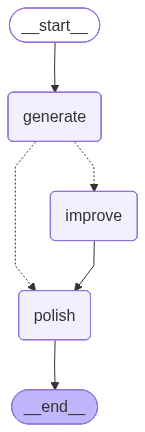

In [8]:
try:
    display(Image(chain_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(chain_graph.get_graph().draw_ascii())

## 4. Pattern 2 — Parallelization

**When to use it:** when several LLM calls are independent — neither needs the other's output. Running them in parallel is *faster* (latency matches the slowest branch, not the sum) and lets you cross-check answers (multiple critics → vote).

**Two flavours:**
1. **Sectioning** — split work across specialised LLMs (joke writer + poem writer + tagline writer).
2. **Voting** — same task, multiple models or temperatures, then aggregate.

![Parallelization](https://www-cdn.anthropic.com/images/4zrzovbb/website/406bb032ca007fd1624f261af717d70e6ca86286-2401x1000.png)

*Diagram: parallelization — fan out independent LLM calls, aggregate the results. Source: [Anthropic](https://www.anthropic.com/engineering/building-effective-agents).*

In LangGraph, parallelism happens automatically when multiple nodes have no dependency between them. The trick: each parallel node writes to a *different* state key, or to a key with a reducer (`Annotated[list, operator.add]`) so writes don't clobber each other.

In [26]:
class CreativeState(TypedDict):
    topic: str
    joke: str
    poem: str
    tagline: str
    combined: str

def write_joke(state: CreativeState):
    return {"joke": llm.invoke(f"Write a one-liner joke about {state['topic']}").content}

def write_poem(state: CreativeState):
    return {"poem": llm.invoke(f"Write a 2-line haiku about {state['topic']}").content}

def write_tagline(state: CreativeState):
    return {"tagline": llm.invoke(f"Write a 5-word tagline for {state['topic']}").content}

def aggregate(state: CreativeState):
    combined = (f"JOKE:    {state['joke']}\n\n"
                f"HAIKU:   {state['poem']}\n\n"
                f"TAGLINE: {state['tagline']}")
    return {"combined": combined}

# Note: node names must NOT collide with state keys, so we prefix with 'write_'
para = StateGraph(CreativeState)
para.add_node("write_joke",    write_joke)
para.add_node("write_poem",    write_poem)
para.add_node("write_tagline", write_tagline)
para.add_node("aggregate",     aggregate)

# Three edges from START — these three nodes run *in parallel*
para.add_edge(START, "write_joke")
para.add_edge(START, "write_poem")
para.add_edge(START, "write_tagline")

# All three converge into the aggregator (LangGraph waits for all)
para.add_edge("write_joke",    "aggregate")
para.add_edge("write_poem",    "aggregate")
para.add_edge("write_tagline", "aggregate")
para.add_edge("aggregate", END)
para_graph = para.compile()

out = para_graph.invoke({"topic": "coffee"})
print(out["combined"])

JOKE:    Why do coffee beans never get in trouble? Because they know how to espresso themselves!

HAIKU:   Steam rises gently,  
Morning's warmth in a cup waits.

TAGLINE: "Awaken Your Senses, Sip Joy."


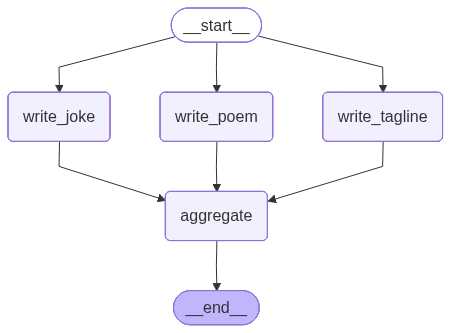

In [27]:
try:
    display(Image(para_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(para_graph.get_graph().draw_ascii())

## 5. Pattern 3 — Routing

**When to use it:** when input falls into a handful of distinct categories and each category needs a different prompt, model, or tool set. Customer-support triage (billing vs technical vs returns), document classifier-then-summariser, or anything where one-prompt-fits-all gives mediocre results.

![Routing](https://www-cdn.anthropic.com/images/4zrzovbb/website/5c0c0e9fe4def0b584c04d37849941da55e5e71c-2401x1000.png)

*Diagram: routing — a classifier dispatches each input to the specialist best suited for it. Source: [Anthropic](https://www.anthropic.com/engineering/building-effective-agents).*

**The mechanism:** a small classifier LLM (with structured output, so the route name is guaranteed valid) writes its decision into state; a `add_conditional_edges` reads that field and dispatches.

Below: classify a customer message as `billing`, `technical`, or `general`, then hand off to a specialist.

In [28]:
class Route(BaseModel):
    """Classifier output — the LLM must pick exactly one of these labels."""
    label: Literal["billing", "technical", "general"] = Field(
        description="Category of the customer's message."
    )

router_llm = llm.with_structured_output(Route)

class SupportState(TypedDict):
    message: str
    route: str
    answer: str

def classify(state: SupportState):
    decision = router_llm.invoke(
        f"Classify this customer message:\n{state['message']}"
    )
    return {"route": decision.label}

def billing_agent(state: SupportState):
    msg = llm.invoke(f"You are a billing specialist. Help with: {state['message']}")
    return {"answer": msg.content}

def technical_agent(state: SupportState):
    msg = llm.invoke(f"You are a senior support engineer. Debug: {state['message']}")
    return {"answer": msg.content}

def general_agent(state: SupportState):
    msg = llm.invoke(f"You are a friendly general agent. Reply to: {state['message']}")
    return {"answer": msg.content}

rt = StateGraph(SupportState)
rt.add_node("classify",  classify)
rt.add_node("billing",   billing_agent)
rt.add_node("technical", technical_agent)
rt.add_node("general",   general_agent)

rt.add_edge(START, "classify")
rt.add_conditional_edges(
    "classify",
    lambda s: s["route"],
    {"billing": "billing", "technical": "technical", "general": "general"}
)
rt.add_edge("billing",   END)
rt.add_edge("technical", END)
rt.add_edge("general",   END)
rt_graph = rt.compile()

for sample in [
    "My credit card was charged twice for the same order.",
    "The app crashes every time I try to upload a file over 5 MB.",
    "Do you guys have a holiday discount this December?",
]:
    out = rt_graph.invoke({"message": sample})
    print(f"INPUT : {sample}")
    print(f"ROUTE : {out['route']}")
    print(f"REPLY : {out['answer'][:160]}...\n")

INPUT : My credit card was charged twice for the same order.
ROUTE : billing
REPLY : I can help you with that! Here are the steps you can take to resolve the issue of being charged twice for the same order:

1. **Review Your Statement**: Double-...

INPUT : The app crashes every time I try to upload a file over 5 MB.
ROUTE : technical
REPLY : When an application crashes during file uploads over a certain size, there are several potential causes to investigate. Here’s a systematic approach to debug th...

INPUT : Do you guys have a holiday discount this December?
ROUTE : general
REPLY : Hello! Thank you for reaching out! Yes, we do have a holiday discount this December. It’s a great time to take advantage of some special offers. If you’d like m...



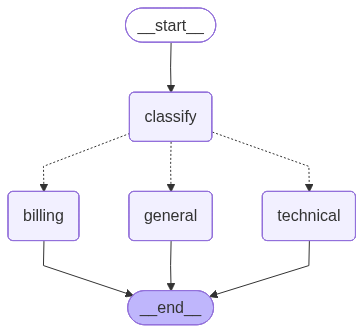

In [29]:
try:
    display(Image(rt_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(rt_graph.get_graph().draw_ascii())

## 6. Pattern 4 — Orchestrator–Worker

**When to use it:** when the *number* and *shape* of subtasks isn't known until you read the input. A research report could be 3 sections or 12. A code refactor could touch 1 file or 40. Routing can't help here because the categories aren't fixed.

![Orchestrator-Workers](https://www-cdn.anthropic.com/images/4zrzovbb/website/8985fc683fae4780fb34eab1365ab78c7e51bc8e-2401x1000.png)

*Diagram: orchestrator-workers — a central LLM dynamically spawns workers and synthesises their outputs. Source: [Anthropic](https://www.anthropic.com/engineering/building-effective-agents).*

**How it works:**
1. **Orchestrator** reads the input and produces a list of subtasks (with structured output).
2. LangGraph's `Send` API spawns one worker per subtask **dynamically at runtime**.
3. Workers run in parallel; each writes into a list-typed state key (`Annotated[list, operator.add]`) so their outputs accumulate.
4. **Synthesizer** combines all worker outputs into a final answer.

Below: an orchestrator plans the sections of a short report, workers draft each section, the synthesizer stitches them together.

In [15]:
class Section(BaseModel):
    name: str = Field(description="Short section title.")
    description: str = Field(description="What this section should cover.")

class Plan(BaseModel):
    sections: List[Section] = Field(description="Ordered list of sections.")

planner_llm = llm.with_structured_output(Plan)

class ReportState(TypedDict):
    topic: str
    sections: list                                       # written by orchestrator
    completed_sections: Annotated[list, operator.add]    # workers append here
    final_report: str                                    # written by synthesizer

class WorkerState(TypedDict):
    section: dict
    completed_sections: Annotated[list, operator.add]

def orchestrator(state: ReportState):
    plan = planner_llm.invoke(
        f"Plan a short technical report on: {state['topic']}. "
        f"Return required number of sections based on the complexity of the topic."
    )
    return {"sections": [s.model_dump() for s in plan.sections]}

def write_section(state: WorkerState):
    sec = state["section"]
    body = llm.invoke(
        f"Write a 3-sentence section titled '{sec['name']}'. "
        f"Cover: {sec['description']}"
    ).content
    return {"completed_sections": [f"## {sec['name']}\n{body}"]}

def assign_workers(state: ReportState):
    """Dynamic fan-out — one Send per planned section."""
    return [Send("write_section", {"section": s}) for s in state["sections"]]

def synthesizer(state: ReportState):
    return {"final_report": "\n\n".join(state["completed_sections"])}

ow = StateGraph(ReportState)
ow.add_node("orchestrator",  orchestrator)
ow.add_node("write_section", write_section)
ow.add_node("synthesizer",   synthesizer)

ow.add_edge(START, "orchestrator")
ow.add_conditional_edges("orchestrator", assign_workers, ["write_section"])
ow.add_edge("write_section", "synthesizer")
ow.add_edge("synthesizer", END)
ow_graph = ow.compile()

out = ow_graph.invoke({"topic": "Explain in detail about Quantum computing. "})
print(out["final_report"])

## Introduction to Quantum Computing
**Introduction to Quantum Computing**  
Quantum computing represents a revolutionary approach to processing information, leveraging the principles of quantum mechanics to perform calculations at unprecedented speeds. Its significance lies in the potential to solve complex problems that are currently intractable for classical computers, such as factoring large numbers and simulating molecular interactions. Unlike classical computing, which relies on bits as the smallest unit of data (0s and 1s), quantum computing utilizes qubits, allowing for superposition and entanglement, which enable a vast increase in computational power and efficiency.

## Fundamental Concepts of Quantum Mechanics
**Fundamental Concepts of Quantum Mechanics**  
Quantum mechanics is grounded in principles such as superposition, where particles can exist in multiple states simultaneously, allowing quantum bits (qubits) to represent both 0 and 1 at the same time. Entanglement furth

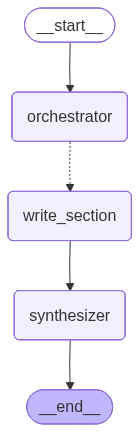

In [31]:
try:
    display(Image(ow_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(ow_graph.get_graph().draw_ascii())

## 7. Pattern 5 — Evaluator–Optimizer

**When to use it:** when there are clear quality criteria a draft can be scored against, and revising on feedback is cheaper than getting it right first try. Translation, code generation with test-runs, copywriting, classification with confidence checks.

![Evaluator-Optimizer](https://www-cdn.anthropic.com/images/4zrzovbb/website/14f51e6406ccb29e695da48b17017e899a6119c7-2401x1000.png)

*Diagram: evaluator-optimizer — one LLM generates, another critiques; loop until the critic accepts. Source: [Anthropic](https://www.anthropic.com/engineering/building-effective-agents).*

**The loop:**
1. **Generator** drafts a response.
2. **Evaluator** judges it (`accept` / `revise`) and produces feedback if revising.
3. If `revise`, the feedback flows back into the generator and the loop continues — capped at N rounds.

Below: write a haiku, evaluate strictly (5-7-5 syllables, vivid imagery), iterate until accepted or after 3 rounds.

In [20]:
class Verdict(BaseModel):
    grade: Literal["accept", "revise"] = Field(description="accept or revise")
    feedback: str = Field(description="What to fix if grade is 'revise'. Empty otherwise.")

evaluator_llm = llm.with_structured_output(Verdict)

class HaikuState(TypedDict):
    topic: str
    haiku: str
    feedback: str
    grade: str
    rounds: int

def generator(state: HaikuState):
    if state.get("feedback"):
        prompt = (f"Rewrite this haiku about '{state['topic']}'. "
                  f"Previous attempt:\n{state['haiku']}\n\n"
                  f"Editor's feedback: {state['feedback']}")
    else:
        prompt = f"Write a haiku about {state['topic']}."
    msg = llm.invoke(prompt)
    return {"haiku": msg.content, "rounds": state.get("rounds", 0) + 1}

def evaluator(state: HaikuState):
    v = evaluator_llm.invoke(
        f"You are a strict haiku editor. Judge this haiku on 5-7-5 syllable structure, "
        f"vivid imagery, and a seasonal cue.\n\nHaiku:\n{state['haiku']}"
    )
    return {"grade": v.grade, "feedback": v.feedback}

def gate(state: HaikuState) -> Literal["generator", "__end__"]:
    # Cap rounds to avoid infinite loops if the evaluator is too strict
    if state["grade"] == "accept" or state["rounds"] >= 5:
        return "__end__"
    return "generator"

eo = StateGraph(HaikuState)
eo.add_node("generator", generator)
eo.add_node("evaluator", evaluator)
eo.add_edge(START, "generator")
eo.add_edge("generator", "evaluator")
eo.add_conditional_edges("evaluator", gate,
                         {"generator": "generator", "__end__": END})
eo_graph = eo.compile()

out = eo_graph.invoke({"topic": "Indian culture", "rounds": 0, "feedback": ""})
print(f"Rounds:  {out['rounds']}")
print(f"Verdict: {out['grade']}")
print(f"\nHaiku:\n{out['haiku']}")
if out["feedback"]:
    print(f"\nLast feedback: {out['feedback']}")

Rounds:  4
Verdict: accept

Haiku:
Vibrant colors glow,  
Spices dance in warm kitchens,  
Harvest moon shines bright.


Colors weave through life,  
Spices dance in every dish,  
Unity in song.

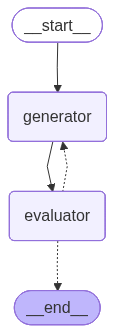

In [19]:
try:
    display(Image(eo_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(eo_graph.get_graph().draw_ascii())

## 8. Pattern 6 — The Agent

**When to use it:** when the steps aren't predictable. The user asks something open-ended, the model needs to *decide* whether it has enough information, *which* tool to call, and *when* to stop. Code-fixing assistants, browser-use agents, deep-research bots.

![Autonomous Agent](https://www-cdn.anthropic.com/images/4zrzovbb/website/58d9f10c985c4eb5d53798dea315f7bb5ab6249e-2401x1000.png)

*Diagram: the autonomous agent — the LLM acts in an environment, observes the result, and decides what to do next. Source: [Anthropic](https://www.anthropic.com/engineering/building-effective-agents).*

**The loop is dead simple:**
```
while True:
    response = llm.invoke(messages)
    if not response.tool_calls:
        break                      # LLM decided it's done
    messages.append(response)
    for call in response.tool_calls:
        result = execute(call)
        messages.append(result)
```

Two ways to build it in LangGraph:
- **Hand-rolled** with `StateGraph` — full control, useful when you need custom step logic.
- **Prebuilt** `create_react_agent` — one line, recommended for most cases.

We show both.

### 8.1 Hand-Rolled Agent

Notice the conditional edge `should_continue` — that's the loop. The agent revisits the LLM after every tool call until the LLM stops calling tools.

In [23]:
(12*7) / 4 + 10

31.0

In [24]:
from langgraph.graph import MessagesState
from langchain_core.messages import ToolMessage

@tool
def divide(a: float, b: float) -> float:
    """Divide a by b."""
    return a / b

agent_tools = [add, multiply, divide]
tools_by_name = {t.name: t for t in agent_tools}
agent_llm = llm.bind_tools(agent_tools)

def llm_call(state: MessagesState):
    sys = SystemMessage(content="You are a math assistant. Use tools for arithmetic.")
    return {"messages": [agent_llm.invoke([sys] + state["messages"])]}

def tool_node(state: MessagesState):
    last = state["messages"][-1]
    results = []
    for call in last.tool_calls:
        out = tools_by_name[call["name"]].invoke(call["args"])
        results.append(ToolMessage(content=str(out), tool_call_id=call["id"]))
    return {"messages": results}

def should_continue(state: MessagesState) -> Literal["tool_node", "__end__"]:
    return "tool_node" if state["messages"][-1].tool_calls else "__end__"

ag = StateGraph(MessagesState)
ag.add_node("llm_call",  llm_call)
ag.add_node("tool_node", tool_node)
ag.add_edge(START, "llm_call")
ag.add_conditional_edges("llm_call", should_continue,
                         {"tool_node": "tool_node", "__end__": END})
ag.add_edge("tool_node", "llm_call")     # the loop back
agent_graph = ag.compile()

out = agent_graph.invoke({"messages": [
    HumanMessage("Multiply 12 and 7, then divide the result by 4 and add 10 and then finally divide by 2.")
]})
for m in out["messages"]:
    m.pretty_print()

================================ Human Message =================================

Multiply 12 and 7, then divide the result by 4 and add 10 and then finally divide by 2.
================================== Ai Message ==================================
Tool Calls:
  multiply (call_5eldLDdbU5E8jIt8Ap8MoOJ8)
 Call ID: call_5eldLDdbU5E8jIt8Ap8MoOJ8
  Args:
    a: 12
    b: 7
  add (call_2n0V0wPpG6ZwZTCqqBMYkJm3)
 Call ID: call_2n0V0wPpG6ZwZTCqqBMYkJm3
  Args:
    a: 10
    b: 0
================================= Tool Message =================================

84
================================= Tool Message =================================

10
================================== Ai Message ==================================
Tool Calls:
  divide (call_rSNSiO8CTCGDzL2Z98Uz88zr)
 Call ID: call_rSNSiO8CTCGDzL2Z98Uz88zr
  Args:
    a: 84
    b: 4
  add (call_afiLN1ewIlHVbJIMtXKBb6yg)
 Call ID: call_afiLN1ewIlHVbJIMtXKBb6yg
  Args:
    a: 10
    b: 0
================================= Tool Message

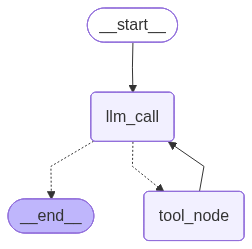

In [35]:
try:
    display(Image(agent_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(agent_graph.get_graph().draw_ascii())

### 8.2 Prebuilt `create_react_agent`

Same behaviour, one line. Use this in real code unless you need to customise the loop.

In [36]:
react_agent = create_react_agent(llm, tools=agent_tools)
out = react_agent.invoke({"messages": [
    HumanMessage("What's (50 + 7) * 2, divided by 6?")
]})
out["messages"][-1].pretty_print()

================================== Ai Message ==================================

The calculation of \((50 + 7) * 2\) divided by 6 results in \(19.0\).


## 9. The Functional API

If a graph is overkill — say you just want sequential `task()` calls with persistence and streaming — LangGraph offers a decorator-based **Functional API**. The compiled output is still a runnable graph, but you write it like normal Python.

Use this for **prompt chaining** and **simple agents** when you don't need fan-out, fan-in, or complex routing.

In [37]:
@task
def outline(topic: str) -> str:
    return llm.invoke(f"Give 3 bullet points to cover for: {topic}").content

@task
def draft(outline_text: str) -> str:
    return llm.invoke(f"Write a paragraph from these bullets:\n{outline_text}").content

@entrypoint()
def write_paragraph(topic: str) -> str:
    bullets = outline(topic).result()
    return draft(bullets).result()

for step in write_paragraph.stream("how transformers attention works",
                                    stream_mode="updates"):
    for k, v in step.items():
        snippet = v if isinstance(v, str) else str(v)
        print(f"[{k}] {snippet[:200]}...\n")

[outline] Sure! Here are three key bullet points that explain how the attention mechanism in transformers works:

1. **Self-Attention Mechanism**: In transformers, self-attention allows the model to weigh the i...

[draft] The attention mechanism in transformers is a powerful tool that enables the model to evaluate the significance of different words within a sequence in relation to one another through a process known a...

[write_paragraph] The attention mechanism in transformers is a powerful tool that enables the model to evaluate the significance of different words within a sequence in relation to one another through a process known a...



## 10. Choosing the Right Pattern

Don't reach for an agent on day one. Start with the simplest pattern that solves your problem and add machinery only when the problem demands it.

| Symptom in your problem | Reach for |
|--------------------------|-----------|
| Fixed steps, each builds on the last | **Prompt Chaining** |
| Independent subtasks, want speed or cross-checks | **Parallelization** |
| Input falls into known categories needing different handling | **Routing** |
| Number/shape of subtasks unknown until runtime | **Orchestrator–Worker** |
| Clear quality bar + cheap revision | **Evaluator–Optimizer** |
| Open-ended, tool-using, unpredictable | **Agent** |

### Workflow vs Agent — the one-liner

> **Workflows** are for when *you* know the plan.  
> **Agents** are for when only the *LLM* can know the plan.

Most production systems are workflows with a small agent embedded inside one node — the best of both worlds: predictable shape, flexible reasoning where it counts.

---

## 11. Reflection Questions

1. **Why does parallelization in LangGraph require a reducer (`Annotated[list, operator.add]`) on the shared key?**  
   Because two parallel nodes writing to the same key would clobber each other. The reducer tells LangGraph how to *merge* concurrent writes — appending to a list, summing numbers, taking max, etc.

2. **What is the difference between Routing and Orchestrator–Worker — they both 'pick what runs next'?**  
   Routing chooses **one** path from a fixed set, decided at graph-design time. Orchestrator–Worker chooses **how many** workers to spawn, with what payloads, decided at *runtime*. Routing → multiplexer. Orchestrator–Worker → fan-out.

3. **Why cap the Evaluator–Optimizer loop at N rounds?**  
   An over-strict evaluator can reject every draft forever, burning tokens. The cap turns an unbounded loop into a bounded one with a known worst-case cost.

4. **When would you NOT use an agent?**  
   When the steps are predictable. Agents add latency (extra LLM round-trips), cost, and debugging difficulty. If a fixed workflow handles 95% of your inputs, use the workflow and only escalate to an agent for the long-tail.

5. **Could the Routing pattern be implemented as an agent?**  
   Yes — give the agent a tool per route and let it pick. But you'd lose the structured-output guarantee, pay for an extra LLM round-trip, and make the path harder to test. Routing is the workflow-shaped answer to the same problem; pick it when categories are stable.